In [1]:
## === Data Analytics ===
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

## === Data Visualization ===
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import logomaker

## === Other ===
from copy import copy

## === My Modules ===
from util import load_obj, save_obj, sci_ticks, showText, PWM2Score, Motif2Seqs


In [2]:
def load_TF_table(lib):
    dfB = pd.read_pickle(f"../tables/PL_{lib}b.pkl")
    dfI = pd.read_pickle(f"../tables/PL_{lib}i.pkl")
    df = pd.DataFrame({"I": dfI['LogGFP'], "B": dfB['LogGFP']})
    df['F'] = df['I'] - df['B']
    return df

def extract_uppercases(input_string):
    uppercase_letters = [char for char in input_string if char.isupper()]
    return ''.join(uppercase_letters)

## ==== Fig S8B: Energy-to-Strength curve ====

In [3]:
def stratified_sample_arrays(ref_arr, other_arr, counts, seed=77777):
    """
    Stratified sampling on two arrays based on the values in ref_arr.

    Parameters
    ----------
    ref_arr : np.ndarray
        1D reference array used for stratification (numeric).
    other_arr : np.ndarray
        Second array to be sampled in parallel (same length as ref_arr).
    counts : list or array-like
        Number of samples to draw from each bin.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    (ref_samples, other_samples)
        Tuple of sampled arrays, each concatenated across bins.
    """
    rs = np.random.RandomState(seed)
    bins = np.linspace(ref_arr.min(), ref_arr.max(), len(counts) + 1)
    indices = np.digitize(ref_arr, bins) - 1

    ref_parts = []
    other_parts = []
    for i, cnt in enumerate(counts):
        idx = np.where(indices == i)[0]
        if len(idx) == 0:
            continue
        chosen = rs.choice(idx, size=cnt, replace=True)
        ref_parts.append(ref_arr[chosen])
        other_parts.append(other_arr[chosen])

    return np.concatenate(ref_parts), np.concatenate(other_parts)

LN10 = np.log(10.0)

def _get_e0(params):
    """
    Your saved files may use either:
      - 'Delta_e0_prime'  (new style, i.e., Δε0′)
      - 'e0'              (older style; already Δε0′)
    Model mapping used during training:
      boltz = exp(beta * (energy + E0 + Eextra*cond))
    and you saved Δε0′ = -E0  ⇒  E0 = -Δε0′
    """
    if 'Delta_e0_prime' in params:
        return -float(params['Delta_e0_prime'])
    elif 'e0' in params:
        return -float(params['e0'])
    else:
        return 0.0

def E2E_Repr3(dGs, params, cond, beta=1.623):
    """
    TetR model (trained with cond in {-1, 0} and rmin correction):
      expr = ln( (Rmin_eff + Rmax * exp(beta * (dGs + E0 + Eextra*cond))) / (1 + exp(...)) )
      where Rmin_eff = Rmin - rmin_correction * cond

    Inputs
    ------
    dGs    : float or array-like
             PWM energy sum for the sequence (must match how you compute it downstream).
    params : dict from Params_TetR.pkl (keys: 'rmin','rmax','Delta_e0_prime' (or 'e0'),
             'Eextra', 'rmin_correction_only_for_TetR')
    cond   : int in {-1, 0}  (basal = -1, induced = 0)
    beta   : float, default 1.623  (≈ 1/(R*T) at 310 K)

    Returns
    -------
    log10(expr)  (numpy array if dGs is array-like, else float)
    """
    dGs = np.asarray(dGs, dtype=np.float64)
    Rmin = float(params['rmin'])
    Rmax = float(params['rmax'])
    E0   = _get_e0(params)
    Eextra = float(params.get('Eextra', 0.0))
    corr   = float(params.get('rmin_correction_only_for_TetR', 0.0))

    # TetR effective Rmin depends on cond (-1/0)
    Rmin_eff = Rmin - corr * float(cond)

    boltz = np.exp(beta * (dGs + E0 + Eextra * float(cond)))
    expr_ln = np.log((Rmin_eff + Rmax * boltz) / (1.0 + boltz))
    return expr_ln / LN10


def E2E_Acti3(dGs, params, cond, beta=1.623):
    """
    LuxR / CueR model (cond in {0,1}, no rmin correction):
      expr = ln( (Rmin + Rmax * exp(beta * (dGs + E0 + Eextra*cond))) / (1 + exp(...)) )

    Inputs
    ------
    dGs    : float or array-like
    params : dict from Params_{LuxR|CueR}.pkl (keys: 'rmin','rmax','Delta_e0_prime' (or 'e0'), 'Eextra')
    cond   : int in {0,1}  (basal = 0, induced = 1)
    beta   : float, default 1.623

    Returns
    -------
    log10(expr)  (numpy array if dGs is array-like, else float)
    """
    dGs = np.asarray(dGs, dtype=np.float64)
    Rmin = float(params['rmin'])
    Rmax = float(params['rmax'])
    E0   = _get_e0(params)
    Eextra = float(params.get('Eextra', 0.0))

    boltz = np.exp(beta * (dGs + E0 + Eextra * float(cond)))
    expr_ln = np.log((Rmin + Rmax * boltz) / (1.0 + boltz))
    return expr_ln / LN10


def getCurve(lib):
    params = load_obj(f'../models/Params_{lib}.pkl')
    limits = {"TetR": (-8, 11), "LuxR": (-9, 10), "CueR": (-6, 19)}
    Min, Max = limits[lib]
    xs = np.linspace(Min, Max, 101)
    
    if lib == 'TetR':
        ysB = E2E_Repr3(xs, params, cond=-1)
        ysI = E2E_Repr3(xs, params, cond= 0)
    else:
        ysB = E2E_Acti3(xs, params, cond=0)
        ysI = E2E_Acti3(xs, params, cond=1)

    return xs, ysB, ysI

def metrics(y, yhat):
    y, yhat = np.asarray(y, float).ravel(), np.asarray(yhat, float).ravel()
    r = np.corrcoef(y, yhat)[0,1] if y.size>1 else np.nan
    sse = np.sum((y-yhat)**2); sst = np.sum((y-y.mean())**2)
    r2 = np.nan if np.isclose(sst,0) else 1 - sse/sst
    mae = np.mean(np.abs(y-yhat))
    return {"r2": r2, "pearson_r": r, "mae": mae}

In [4]:
def showCurve(ax, df, params):
    """
    Plot scatter points and theoretical curves for a given transcription factor library.

    Parameters:
        ax (matplotlib.axes.Axes): The axes to plot on.
        df (pandas.DataFrame): DataFrame containing 'dG' (free energy), 'B' (basal expression), and 'I' (induction) data.
        params (dict): Dictionary containing parameters for the theoretical curve calculations.

    Returns:
        MAE (mean absolute error)
    """
    ## Define motif for each library and get indices from Motif2Seqs function
    lib = params['tf']

    dfB = df.dropna()
    dfI = df.dropna()
    
    if lib == 'TetR':
        y_predB = E2E_Repr3(-dfB['dG'], params, cond=-1)
        y_predI = E2E_Repr3(-dfI['dG'], params, cond= 0)
    else:
        y_predB = E2E_Acti3(-dfB['dG'], params, cond=0)
        y_predI = E2E_Acti3(-dfI['dG'], params, cond=1)

    y_exprB = dfB['B']
    y_exprI = dfI['I']

    xs, ysB, ysI = getCurve(lib)
    line_gray  = '#606060'
    line_green = '#229922'
    ax.plot(xs, ysB, color='k', linewidth=0.8)
    ax.plot(xs, ysI, color='k', linewidth=0.8)

    ## Scatter plot for basal expression and induction data points
    dot_gray  = '#b3b3b3'
    dot_green = '#85e085'
    ax.scatter(-dfB['dG'], y_exprB, s=1, alpha=0.7, color=dot_gray , edgecolor='None')
    ax.scatter(-dfI['dG'], y_exprI, s=1, alpha=0.7, color=dot_green, edgecolor='None')

    ## Highlight the outlier variants
    if lib == 'TetR':
        outliers = list(Motif2Seqs('NNNacaAaNNTt'))
        ax.scatter(-dfB['dG'].loc[outliers], y_exprB.loc[outliers], s=1, edgecolor='None', color='#edce5f')
        ax.scatter(-dfI['dG'].loc[outliers], y_exprI.loc[outliers], s=1, edgecolor='None', color='#edce5f')
    
    ## Highlight the wild type variants
    wild_type = {'TetR': 'TTGacaTaTTTt', 'LuxR': 'tTTacGTaTAGt', 'CueR': 'TTGaccTaACCt'}
    ax.scatter(-dfB['dG'].loc[wild_type[lib]], y_exprB.loc[wild_type[lib]], s=8, color='red', linewidth=0, zorder=2)
    ax.scatter(-dfI['dG'].loc[wild_type[lib]], y_exprI.loc[wild_type[lib]], s=8, color='red', linewidth=0, zorder=2)
    
    ## Highlight the consensus variants
    consensus = {'TetR': 'TTGacaTaTAAt', 'LuxR': 'tTGacATaTAAt', 'CueR': 'TTGaccTaTAAt'}
    ax.scatter(-dfB['dG'].loc[consensus[lib]], y_exprB.loc[consensus[lib]], s=8, color='blue', linewidth=0, zorder=2)
    ax.scatter(-dfI['dG'].loc[consensus[lib]], y_exprI.loc[consensus[lib]], s=8, color='blue', linewidth=0, zorder=2)
        
    ## Y-axis limits
    dots = np.concatenate([y_exprB.values, y_exprI.values])
    yMin = np.nanmin(dots)
    yMax = np.max(ysI)
    interval = (yMax - yMin)
    ax.set_ylim(yMin-interval*0.06, yMax+interval*0.18)

    ## Print statistical metrices
    y_expr = np.concatenate([y_exprB, y_exprI])
    y_pred = np.concatenate([y_predB, y_predI])
    y_expr_s, y_pred_s = stratified_sample_arrays(y_expr, y_pred, [1500]*6)
    print(f"{lib}: ", metrics(y_expr_s, y_pred_s))
    
    return None

TetR:  {'r2': 0.6096940979414569, 'pearson_r': 0.8346941862005653, 'mae': 0.3151704686731595}
LuxR:  {'r2': 0.8719730401207866, 'pearson_r': 0.9345266101356223, 'mae': 0.1847900109845552}
CueR:  {'r2': 0.9303646687337744, 'pearson_r': 0.9657300180245603, 'mae': 0.12222532171890198}


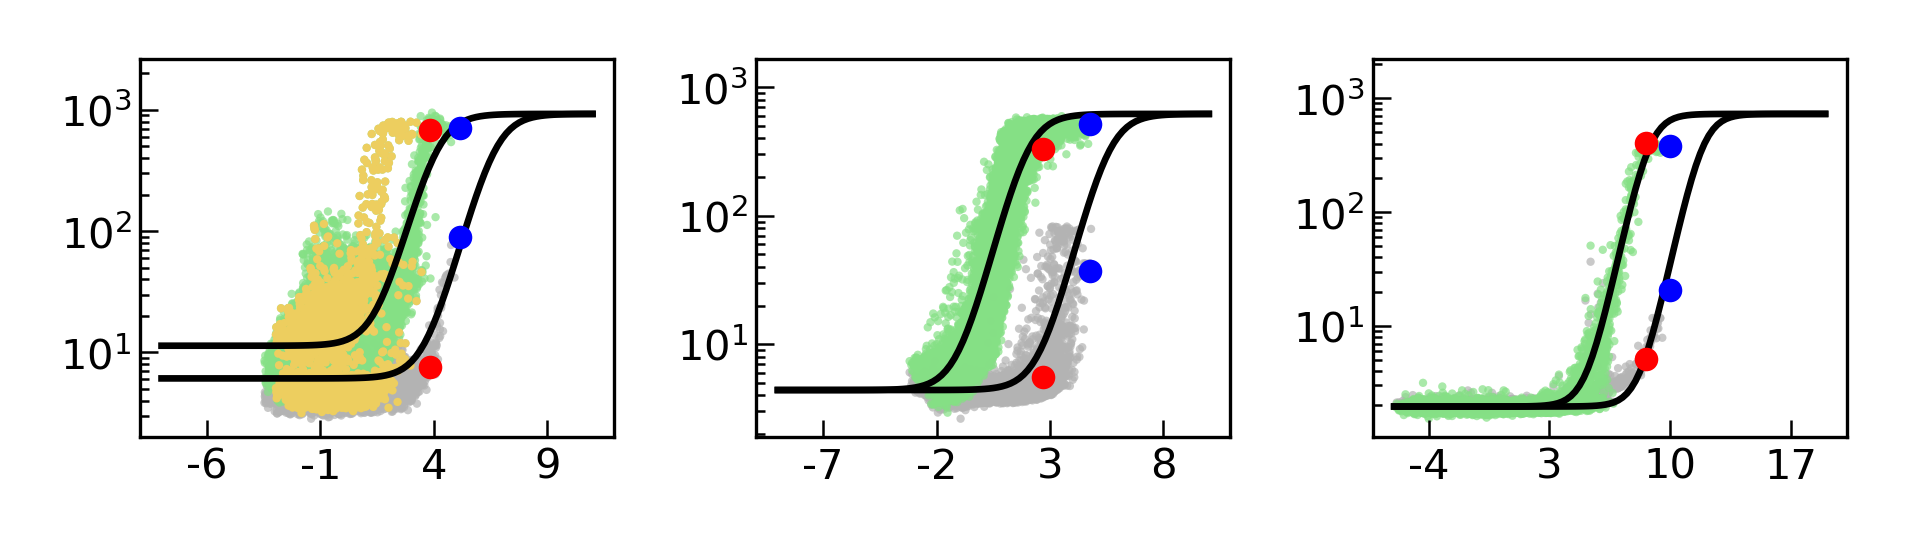

In [5]:
libs = ["TetR", "LuxR", "CueR"]
fig, axes = plt.subplots(1, 3, figsize=(85/25.4, 20/25.4), dpi=600, sharey=False)

for ax, lib in zip(axes, libs):
    
    df = load_TF_table(lib)    
    params = load_obj(f'../models/Params_{lib}.pkl')
    dG_list = PWM2Score(params['pwm'])
    df['dG'] = np.array([dG_list[s] for s in df.index.map(extract_uppercases)])
    
    showCurve(ax, df, params)

for ax in axes:
    sci_ticks(ax, 'y', ticksize=5, pad=1)
    ax.tick_params(axis='x', which='both', direction='in', labelsize=5, width=0.3, length=2, pad=1.2)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

axes[0].set_xticks([-6, -1,  4,  9])
axes[1].set_xticks([-7, -2,  3,  8])
axes[2].set_xticks([-4,  3, 10, 17])

## ==== Final adjustments and saving ====
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

plt.subplots_adjust(left=0.10, right=0.95, bottom=0.15, top=0.95, wspace=0.3)
plt.savefig("../figures/FigS8B_E2Scurve.png")
# plt.savefig("../figures/FigS8B_E2Scurve.svg")
plt.show()

## ==== Fig S8C: Energy logo ====

In [6]:
def pwm4logo(df, positions, nucleotides):

    def insert_row(df, new_row, position):
        if isinstance(new_row, dict):
            new_row = pd.DataFrame(new_row, index=[position])
        elif isinstance(new_row, list):
            new_row = pd.DataFrame([new_row], columns=df.columns, index=[position])
        else:
            raise ValueError("Invalid input format. Expected dictionary or list.")

        df_before = df.iloc[:position]
        df_after = df.iloc[position:]
        df = pd.concat([df_before, new_row, df_after]).reset_index(drop=True)
        return df


    df[u'А'] = 0
    df[u'С'] = 0
    df[u'Т'] = 0

    pseudoN = {
        u'А': [0, 0, 0, 0, -2, 0, 0],
        u'С': [0, 0, 0, 0, 0, -2, 0],
        u'Т': [0, 0, 0, 0, 0, 0, -2],
        }

    for position, N in zip(positions, nucleotides):
        df = insert_row(df, pseudoN[N], position)

    return df

def pwm4logo_TF(pwm, mode='TetR'):
    return {
        'TetR': pwm4logo(pwm, [3, 4, 5, 7, 11], u'АСААТ'),
        'LuxR': pwm4logo(pwm, [0, 3, 4, 7, 11], u'ТАСАТ'),
        'CueR': pwm4logo(pwm, [3, 4, 5, 7, 11], u'АССАТ')}[mode]

def showLogo(ax, df):
    
    ## custom color scheme
    color_scheme = {
        'A' : 'green',
        'C' : 'blue',
        'G' : 'orange',
        'T' : 'red',
        u'АСᏀТ': '#dfdfdf'
        }

    ## create Logo object
    pwm_logo = logomaker.Logo(df,
                              shade_below=.4,
                              fade_below=.4,
                              font_name='DejaVu Sans',
                              color_scheme=color_scheme,
                              ax=ax)

    ## style using Logo methods
    pwm_logo.style_spines(visible=False)
    pwm_logo.style_spines(spines=['left', 'bottom'], visible=True)

    ax.axhline(0.0, color='black', lw=0.4)
    ax.axvline(5.5, color='black', lw=0.4)
    ax.patch.set_edgecolor('black')
    ax.patch.set_linewidth(0.4)
    
    return pwm_logo

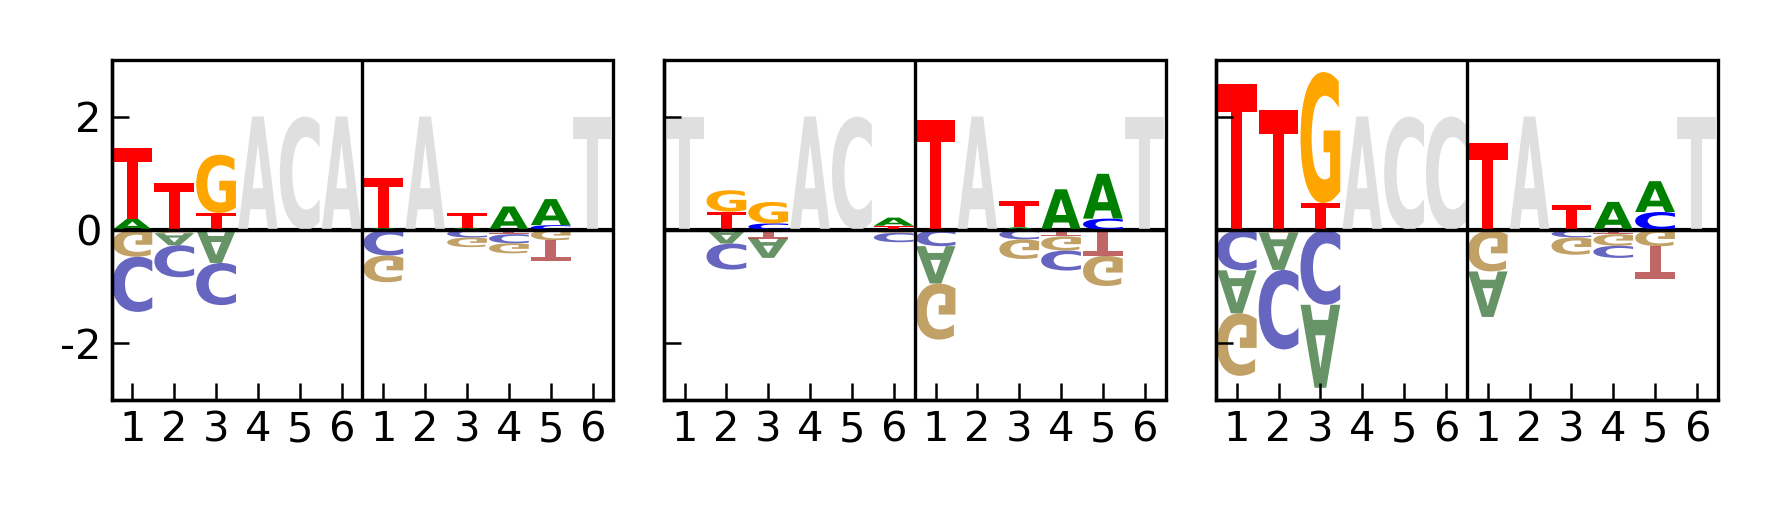

In [7]:
libs = ["TetR", "LuxR", "CueR"]
fig, axes = plt.subplots(1, 3, figsize=(80/25.4, 18/25.4), dpi=600, sharey=True)

for ax, lib in zip(axes, libs):
    params = load_obj(f'../models/Params_{lib}.pkl')
    showLogo(ax, -pwm4logo_TF(copy(params['pwm']), mode=lib))

    ax.set(
        xlim=(-0.5, 11.5),
        ylim=(-3, 3),
        xticks=np.arange(12),
        yticks=[-2, 0, 2],
        )

    ax.set_xticklabels(['1', '2', '3', '4', '5', '6', '1', '2', '3', '4', '5', '6'])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=5, width=0.3, length=2, pad=1.2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

plt.subplots_adjust(left=0.10, right=0.95, bottom=0.15, top=0.95, wspace=0.1)
plt.savefig("../figures/FigS8C_Logo.svg")
plt.show()

## ==== Fig S8D: Energy comparison ====

In [8]:
def pearsonr_without_nan(x, y):
    valid_indices = ~np.isnan(x) & ~np.isnan(y)
    x_valid = x[valid_indices]
    y_valid = y[valid_indices]
    return pearsonr(x_valid, y_valid)

def calculate_slope_ignore_nan(x, y):
    """
    Calculate the slope of the linear regression line while ignoring NaN values.

    Parameters:
        x (numpy.ndarray): The independent variable (predictor) data.
        y (numpy.ndarray): The dependent variable (target) data.

    Returns:
        float: The slope of the linear regression line while ignoring NaN values.
    """
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, _ = np.polyfit(x[mask], y[mask], 1)
    return slope

def pwm4comparison(pwm, mode):
    
    if mode == 'TetR':
        pwm35 = pd.DataFrame(np.repeat(np.nan, 24).reshape(6, 4), columns=['A', 'C', 'G', 'T'])
        pwm35.loc[[0, 1, 2]] = pwm.loc[[0, 1, 2]].values
        pwm10 = pd.DataFrame(np.repeat(np.nan, 24).reshape(6, 4), columns=['A', 'C', 'G', 'T'])
        pwm10.loc[[0, 2, 3, 4]] = pwm.loc[[3, 4, 5, 6]].values
        
    elif mode == 'LuxR':
        pwm35 = pd.DataFrame(np.repeat(np.nan, 24).reshape(6, 4), columns=['A', 'C', 'G', 'T'])
        pwm35.loc[[1, 2, 5]] = pwm.loc[[0, 1, 2]].values
        pwm10 = pd.DataFrame(np.repeat(np.nan, 24).reshape(6, 4), columns=['A', 'C', 'G', 'T'])
        pwm10.loc[[0, 2, 3, 4]] = pwm.loc[[3, 4, 5, 6]].values
        
    elif mode == 'CueR':
        pwm35 = pd.DataFrame(np.repeat(np.nan, 24).reshape(6, 4), columns=['A', 'C', 'G', 'T'])
        pwm35.loc[[0, 1, 2]] = pwm.loc[[0, 1, 2]].values
        pwm10 = pd.DataFrame(np.repeat(np.nan, 24).reshape(6, 4), columns=['A', 'C', 'G', 'T'])
        pwm10.loc[[0, 2, 3, 4]] = pwm.loc[[3, 4, 5, 6]].values
        
    return pwm35, pwm10

def PairwiseComparison(ax, pwm35, pwmC35, pwm10, pwmC10):
    
    def plot_pair(ax, x, y, color, text_y):

        ## Scatter
        ax.scatter(-x, -y, color=color, s=6.5, alpha=0.6, edgecolors='None')

        ## Set limits
        xlim = ax.set_xlim([-3, 2])
        ylim = ax.set_ylim([-2, 3])

        ## Pearson r and display
        r, p = pearsonr_without_nan(x.values, y.values)
        # ax.text(2.8, text_y, fr"$r={r:.3f}, P={p:.3f}$", color=color, fontsize=5, ha='right', va='center')
        # print(f"r={r}\nP={p}\n")

        return ax

    ## Plot -35 pair on main axis
    plot_pair(ax, pwmC35, pwm35, color='blue', text_y=-1.5)
    plot_pair(ax, pwmC10, pwm10, color='red',  text_y=-2.4)

    ## Style
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    return None

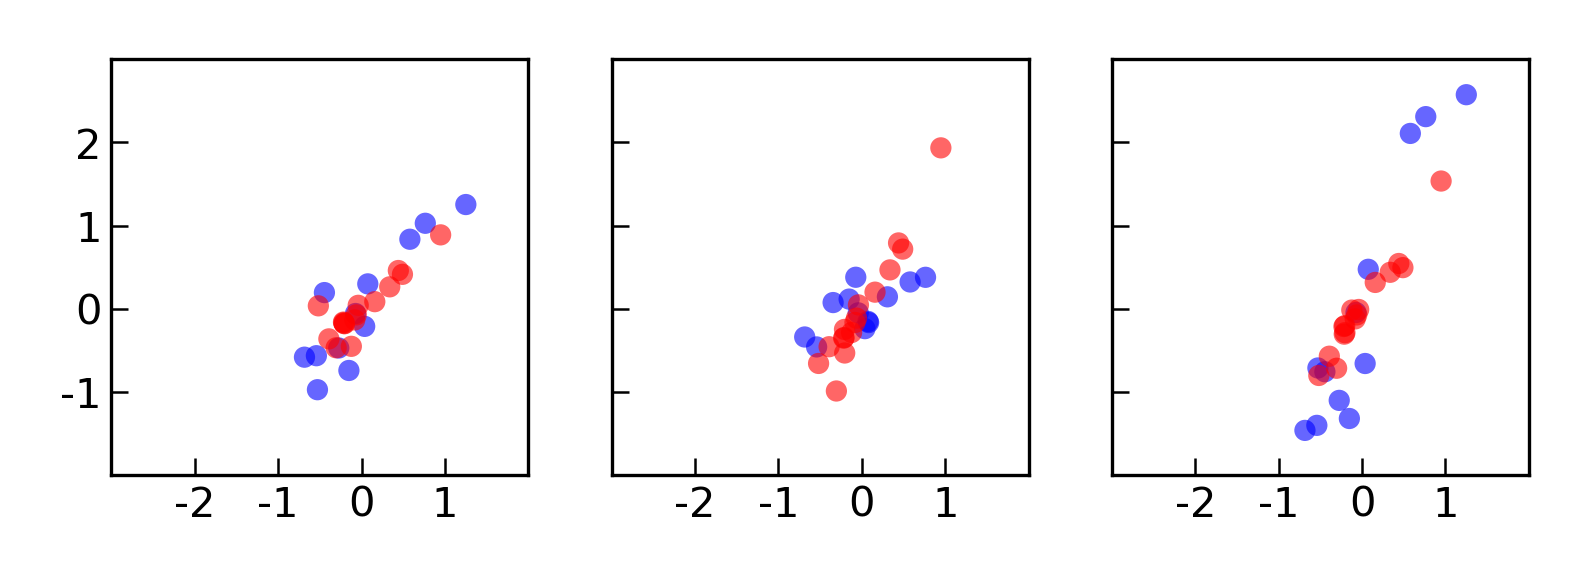

In [9]:
libs = ["TetR", "LuxR", "CueR"]
paramsC = load_obj('../models/Params_C17.pkl')
fig, axes = plt.subplots(1, 3, figsize=(80/25.4, 22/25.4), dpi=600, sharey=True)

for ax, lib in zip(axes.flatten(), libs):
    params = load_obj(f"../models/Params_{lib}.pkl")
    pwm35, pwm10 = pwm4comparison(copy(params['pwm']), mode=lib)
    PairwiseComparison(ax, pwm35, paramsC['pwm35'], pwm10, paramsC['pwm10'])
    
    ax.set_xticks([-2, -1,  0,  1])
    ax.set_yticks([-1,  0,  1,  2])
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.tick_params(axis='both', which='both', direction='in', labelsize=5, width=0.3, length=2, pad=1.2)

plt.subplots_adjust(left=0.15, right=0.90, bottom=0.15, top=0.95, wspace=0.2)
plt.savefig("../figures/FigS8D_LogoCompare.svg")
plt.show()